# ECE 567 Module 9 Homework  
## Generative AI Masterclass: CVAE Latent Dimension Optimization and CGAN Extended Training

This notebook completes the two homework questions:

1. **Homework 1:** Optimizing Convolutional VAE latent dimensions using `latent_dim=10` and `latent_dim=50`.
2. **Homework 2:** Extended Convolutional GAN training with adjusted TTUR learning rates.

All experiments use the **Fashion-MNIST** dataset and are designed to run in **Google Colab**.
**Corrected version:** CVAE preprocessing/loss/decoder are aligned with the reference notebooks to make the loss scale comparable.


In [1]:
# ============================================================
# Setup
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# ============================================================
# Dataset: Fashion-MNIST
# ============================================================

# The reference notebooks use Tanh output in both CVAE and GAN.
# Therefore, images are normalized from [0, 1] to [-1, 1].
batch_size = 128
IMG_SIZE = 28 * 28

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.12MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 58.3MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.7MB/s]


Train samples: 60000
Test samples: 10000


# Homework 1: Optimizing Convolutional VAE Latent Dimensions

In this section, a Convolutional Variational Autoencoder is trained using two different latent dimensionalities:

- `latent_dim = 10`
- `latent_dim = 50`

Both models are trained for **10 epochs** using **beta = 1.5**.  
After each training run, the notebook visualizes:

1. Original and reconstructed Fashion-MNIST images.
2. Latent space interpolation between two test images.
3. Training loss curves.

The goal is to compare how the size of the latent representation affects reconstruction quality and generative smoothness.

In [3]:
# ============================================================
# Convolutional Variational Autoencoder
# ============================================================

class ConvolutionalVAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 1 x 28 x 28 -> 32 x 14 x 14 -> 64 x 7 x 7
        # This version follows the reference structure more closely by using
        # BatchNorm layers and 3x3 convolutional kernels.
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.flatten_dim = 64 * 7 * 7
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # Decoder: latent vector -> 64 x 7 x 7 -> 32 x 14 x 14 -> 1 x 28 x 28
        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)

    def encode(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.view(-1, self.flatten_dim)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        x = F.relu(self.fc_decode(z))
        x = x.view(-1, 64, 7, 7)
        x = F.relu(self.bn3(self.deconv1(x)))
        x_recon = torch.tanh(self.deconv2(x))
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [4]:
# ============================================================
# CVAE Loss and Training Function
# ============================================================

# Important correction:
# Since the input images are normalized to [-1, 1] and the decoder uses Tanh,
# the reconstruction loss is changed from BCE to MSE.
# This makes the CVAE loss scale comparable to the reference notebooks.

def cvae_loss_function(recon_x, x, mu, logvar, beta=1.5):
    recon_loss = F.mse_loss(
        recon_x.view(-1, IMG_SIZE),
        x.view(-1, IMG_SIZE),
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss


def train_cvae(model, train_loader, optimizer, epochs=10, beta=1.5):
    model.train()
    history = {
        "total_loss": [],
        "recon_loss": [],
        "kl_loss": []
    }

    for epoch in range(1, epochs + 1):
        total_loss_sum = 0.0
        recon_loss_sum = 0.0
        kl_loss_sum = 0.0

        for images, _ in train_loader:
            images = images.to(device)

            optimizer.zero_grad()
            recon, mu, logvar = model(images)
            loss, recon_loss, kl_loss = cvae_loss_function(
                recon, images, mu, logvar, beta=beta
            )

            loss.backward()
            optimizer.step()

            total_loss_sum += loss.item()
            recon_loss_sum += recon_loss.item()
            kl_loss_sum += kl_loss.item()

        # Divide by the full dataset size, not by the number of batches.
        # This reports average loss per image and keeps the scale around the
        # same range as the reference results.
        avg_total = total_loss_sum / len(train_loader.dataset)
        avg_recon = recon_loss_sum / len(train_loader.dataset)
        avg_kl = kl_loss_sum / len(train_loader.dataset)

        history["total_loss"].append(avg_total)
        history["recon_loss"].append(avg_recon)
        history["kl_loss"].append(avg_kl)

        print(
            f"CVAE Epoch [{epoch}/{epochs}] | "
            f"Total Loss: {avg_total:.4f} | "
            f"Recon Loss: {avg_recon:.4f} | "
            f"KLD: {avg_kl:.4f}"
        )

    return history

In [5]:
# ============================================================
# Helper Functions for CVAE Visualization
# ============================================================

# Convert images from [-1, 1] back to [0, 1] for plotting.
def denormalize_for_plot(x):
    return torch.clamp((x + 1) / 2, 0, 1)


def show_cvae_reconstructions(model, data_loader, num_images=8, title="CVAE Reconstructions"):
    model.eval()

    images, labels = next(iter(data_loader))
    images = images[:num_images].to(device)

    with torch.no_grad():
        recon, _, _ = model(images)

    images = denormalize_for_plot(images.cpu())
    recon = denormalize_for_plot(recon.cpu())

    combined_images = torch.cat([images, recon], dim=0)
    grid = make_grid(combined_images, nrow=num_images, normalize=False)

    plt.figure(figsize=(15, 3))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.title(title + "\nOriginal Images: Top Row | Reconstructed Images: Bottom Row")
    plt.axis("off")
    plt.show()


def show_latent_interpolation(model, data_loader, steps=10, title="Latent Space Interpolation"):
    model.eval()

    with torch.no_grad():
        latent_dim = model.latent_dim
        z1 = torch.randn(1, latent_dim, device=device)
        z2 = torch.randn(1, latent_dim, device=device)

        interpolated_images = []
        for alpha in np.linspace(0, 1, steps):
            z_interp = (1 - alpha) * z1 + alpha * z2
            decoded = model.decode(z_interp)
            interpolated_images.append(decoded.cpu())

    interpolated_images = denormalize_for_plot(torch.cat(interpolated_images, dim=0))
    grid = make_grid(interpolated_images, nrow=steps, normalize=False)

    plt.figure(figsize=(15, 3))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


def plot_cvae_history(history, title="CVAE Training Loss"):
    plt.figure(figsize=(8, 5))
    plt.plot(history["total_loss"], label="Total Loss")
    plt.plot(history["recon_loss"], label="Reconstruction Loss")
    plt.plot(history["kl_loss"], label="KLD Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Average Loss per Image")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## Experiment 1: CVAE with `latent_dim = 10`

This model uses a compact latent representation.  
A smaller latent space may encourage stronger compression and smoother structure, but it can also lose fine visual details.

Training CVAE with latent_dim = 10
CVAE Epoch [1/10] | Total Loss: 124.0255 | Recon Loss: 101.0595 | KLD: 15.3106
CVAE Epoch [2/10] | Total Loss: 85.8614 | Recon Loss: 63.6447 | KLD: 14.8111
CVAE Epoch [3/10] | Total Loss: 81.5411 | Recon Loss: 59.3286 | KLD: 14.8083
CVAE Epoch [4/10] | Total Loss: 78.9527 | Recon Loss: 56.6912 | KLD: 14.8410
CVAE Epoch [5/10] | Total Loss: 77.2279 | Recon Loss: 54.9325 | KLD: 14.8636
CVAE Epoch [6/10] | Total Loss: 75.9468 | Recon Loss: 53.5938 | KLD: 14.9020
CVAE Epoch [7/10] | Total Loss: 75.0982 | Recon Loss: 52.7261 | KLD: 14.9147
CVAE Epoch [8/10] | Total Loss: 74.3372 | Recon Loss: 51.9201 | KLD: 14.9447
CVAE Epoch [9/10] | Total Loss: 73.7024 | Recon Loss: 51.2448 | KLD: 14.9717
CVAE Epoch [10/10] | Total Loss: 73.3049 | Recon Loss: 50.8507 | KLD: 14.9695


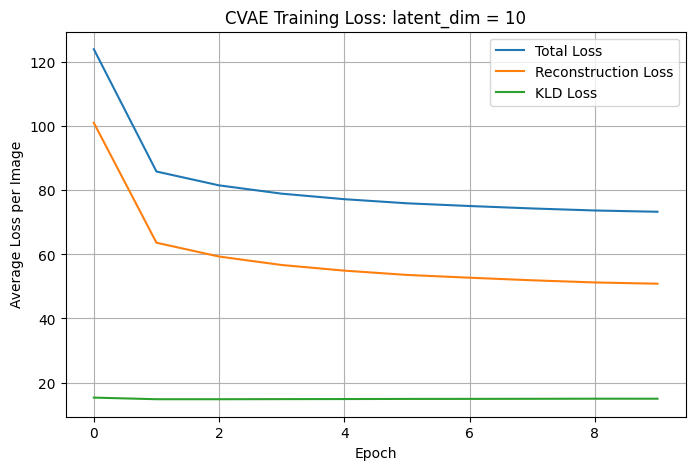

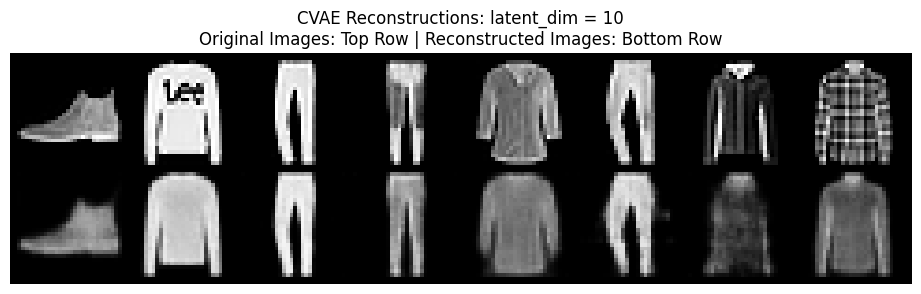

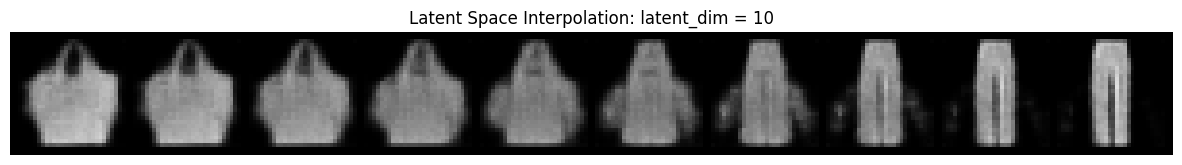

In [6]:
# ============================================================
# CVAE Experiment 1: latent_dim = 10
# ============================================================

latent_dim_10 = 10
beta = 1.5
cvae_epochs = 10

cvae_10 = ConvolutionalVAE(latent_dim=latent_dim_10).to(device)
optimizer_10 = optim.Adam(cvae_10.parameters(), lr=1e-3)

print("Training CVAE with latent_dim = 10")
history_cvae_10 = train_cvae(
    model=cvae_10,
    train_loader=train_loader,
    optimizer=optimizer_10,
    epochs=cvae_epochs,
    beta=beta
)

plot_cvae_history(history_cvae_10, title="CVAE Training Loss: latent_dim = 10")
show_cvae_reconstructions(
    cvae_10,
    test_loader,
    num_images=8,
    title="CVAE Reconstructions: latent_dim = 10"
)
show_latent_interpolation(
    cvae_10,
    test_loader,
    steps=10,
    title="Latent Space Interpolation: latent_dim = 10"
)

## Experiment 2: CVAE with `latent_dim = 50`

This model uses a larger latent representation.  
A larger latent space can preserve more information about the input images, which may improve reconstruction sharpness. However, if the latent space becomes too flexible, interpolation can sometimes become less regular.

Training CVAE with latent_dim = 50
CVAE Epoch [1/10] | Total Loss: 125.7860 | Recon Loss: 93.4136 | KLD: 21.5816
CVAE Epoch [2/10] | Total Loss: 90.9177 | Recon Loss: 63.2363 | KLD: 18.4542
CVAE Epoch [3/10] | Total Loss: 84.1130 | Recon Loss: 57.8867 | KLD: 17.4842
CVAE Epoch [4/10] | Total Loss: 81.0015 | Recon Loss: 55.3538 | KLD: 17.0984
CVAE Epoch [5/10] | Total Loss: 78.8802 | Recon Loss: 53.4803 | KLD: 16.9333
CVAE Epoch [6/10] | Total Loss: 77.3759 | Recon Loss: 52.1942 | KLD: 16.7878
CVAE Epoch [7/10] | Total Loss: 76.2870 | Recon Loss: 51.1475 | KLD: 16.7596
CVAE Epoch [8/10] | Total Loss: 75.4724 | Recon Loss: 50.4023 | KLD: 16.7134
CVAE Epoch [9/10] | Total Loss: 74.6977 | Recon Loss: 49.7138 | KLD: 16.6559
CVAE Epoch [10/10] | Total Loss: 74.2447 | Recon Loss: 49.2731 | KLD: 16.6477


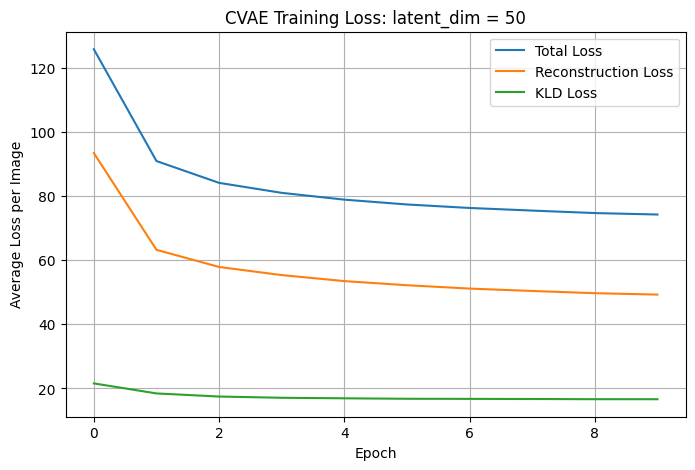

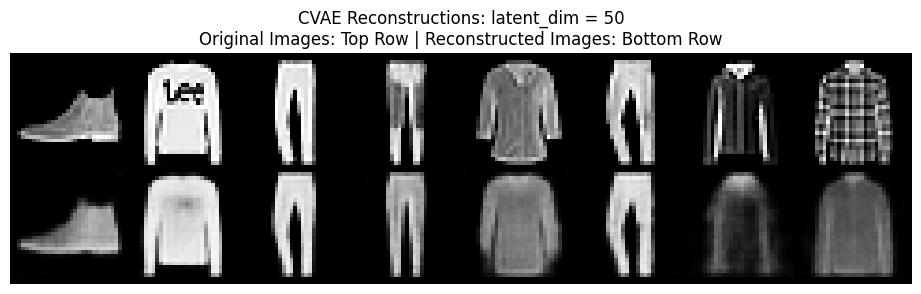

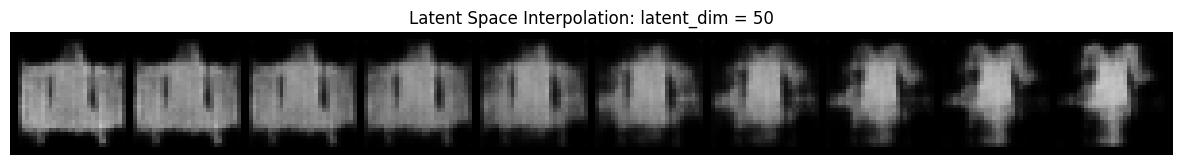

In [7]:
# ============================================================
# CVAE Experiment 2: latent_dim = 50
# ============================================================

latent_dim_50 = 50

# Important: re-instantiate both the model and optimizer
cvae_50 = ConvolutionalVAE(latent_dim=latent_dim_50).to(device)
optimizer_50 = optim.Adam(cvae_50.parameters(), lr=1e-3)

print("Training CVAE with latent_dim = 50")
history_cvae_50 = train_cvae(
    model=cvae_50,
    train_loader=train_loader,
    optimizer=optimizer_50,
    epochs=cvae_epochs,
    beta=beta
)

plot_cvae_history(history_cvae_50, title="CVAE Training Loss: latent_dim = 50")
show_cvae_reconstructions(
    cvae_50,
    test_loader,
    num_images=8,
    title="CVAE Reconstructions: latent_dim = 50"
)
show_latent_interpolation(
    cvae_50,
    test_loader,
    steps=10,
    title="Latent Space Interpolation: latent_dim = 50"
)

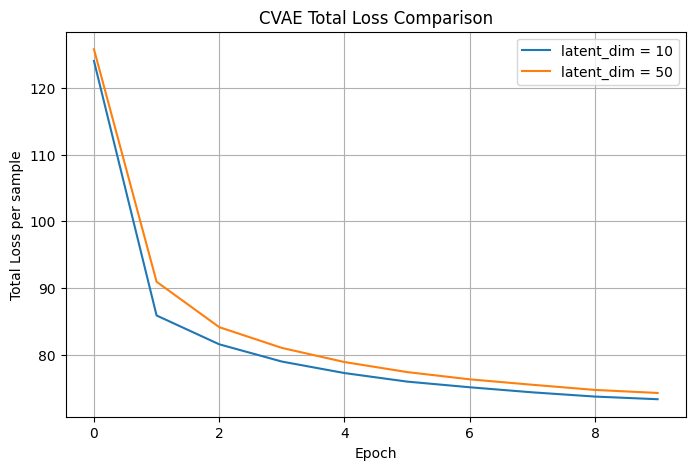

Final CVAE loss comparison:
latent_dim = 10 | Final total loss: 73.3049
latent_dim = 50 | Final total loss: 74.2447


In [8]:
# ============================================================
# Side-by-Side Loss Comparison
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history_cvae_10["total_loss"], label="latent_dim = 10")
plt.plot(history_cvae_50["total_loss"], label="latent_dim = 50")
plt.xlabel("Epoch")
plt.ylabel("Total Loss per sample")
plt.title("CVAE Total Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

print("Final CVAE loss comparison:")
print(f"latent_dim = 10 | Final total loss: {history_cvae_10['total_loss'][-1]:.4f}")
print(f"latent_dim = 50 | Final total loss: {history_cvae_50['total_loss'][-1]:.4f}")

The final total loss was slightly lower for `latent_dim = 10` (**73.30**) than for `latent_dim = 50` (**74.24**). However, the visual reconstructions suggest that `latent_dim = 50` preserved slightly more detail, while `latent_dim = 10` produced smoother interpolation. Therefore, the best latent dimension depends on whether reconstruction sharpness or latent smoothness is prioritized.

## Homework 1 Analysis: Effect of Latent Dimension on Convolutional VAE Performance

In this experiment, two Convolutional VAE models were trained on the Fashion-MNIST dataset using two different latent space sizes: `latent_dim = 10` and `latent_dim = 50`. Both models were trained for 10 epochs with `beta = 1.5`. To make the comparison fair, the model and optimizer were re-instantiated separately for each experiment. Therefore, the results represent two independent training runs under the same training conditions except for the latent dimension size.

According to the training loss results, both models showed a clear decrease in total loss during training. For `latent_dim = 10`, the total loss decreased from approximately **124.03** in the first epoch to **73.30** at the end of epoch 10. For `latent_dim = 50`, the total loss decreased from approximately **125.79** to **74.24**. This shows that both models learned meaningful latent representations and improved their reconstruction ability over the 10 epochs. The loss curve also shows that the largest improvement happened during the first two epochs, and then the decrease became more gradual. This behavior is expected because the model quickly learns the basic structure of Fashion-MNIST images at the beginning, while later epochs mainly refine smaller visual details.

When comparing the final losses, `latent_dim = 10` achieved a slightly lower final total loss (**73.30**) than `latent_dim = 50` (**74.24**). However, this does not necessarily mean that the smaller latent dimension is always visually better. The total VAE loss includes both reconstruction loss and KL divergence loss. The `latent_dim = 50` model has a larger latent space, so it can encode more information, but it also has a larger KL divergence contribution. In my results, the final reconstruction loss of `latent_dim = 50` was slightly lower than the reconstruction loss of `latent_dim = 10`, while the KLD value was higher. This means that the larger latent space helped the model reconstruct images with slightly more detail, but it also increased the regularization penalty.

The reconstruction results visually support this interpretation. In the `latent_dim = 10` reconstruction grid, the model successfully reconstructed the general shapes of shoes, trousers, shirts, and jackets. However, some reconstructed images looked smoother and blurrier, especially for more detailed clothing items such as patterned shirts or jackets. This suggests that the smaller latent space compressed the image information more strongly. As a result, it preserved the main object structure but lost some fine-grained texture and edge details.

For `latent_dim = 50`, the reconstructed images appeared slightly sharper and more detailed in several examples. The general clothing outlines were preserved well, and some items showed clearer structure compared to the `latent_dim = 10` results. This is reasonable because a 50-dimensional latent space gives the encoder more capacity to store visual information from the input image. Therefore, the decoder receives a richer representation and can reconstruct more detailed outputs.

The latent space interpolation results show another important difference. For `latent_dim = 10`, the interpolation looked relatively smooth and gradual. The generated samples changed from one clothing-like shape to another in a more continuous way. This suggests that the smaller latent space produced a more compact and regular representation. Since the model has fewer latent variables, it is forced to organize the data in a simpler latent structure, which can make interpolation smoother.

For `latent_dim = 50`, the interpolation also produced meaningful Fashion-MNIST-like outputs, but the transition appeared less smooth and slightly more variable. Some generated shapes changed more abruptly and looked blurrier during the transition. This can happen because a larger latent space gives the model more freedom, but it may also make the latent manifold less compact. Therefore, random interpolation between two points may pass through regions that are not as well organized or not as strongly regularized.

Overall, based on my visual observations, `latent_dim = 50` appears to provide slightly better reconstruction quality because it preserves more image detail and produces sharper reconstructed clothing shapes. However, `latent_dim = 10` appears to produce smoother latent space interpolation because the smaller bottleneck forces the model to learn a more compact and regular latent representation. Therefore, if the main goal is sharper reconstruction, `latent_dim = 50` is preferable. If the main goal is smoother and more regular generative transitions, `latent_dim = 10` may be better.

For Fashion-MNIST, I would choose `latent_dim = 50` as the better generative setting overall because the reconstructed images contain slightly more visual detail, and the final reconstruction loss is lower. However, the difference is not very large, and the `latent_dim = 10` model is also successful because it achieves a slightly lower total loss and smoother interpolation. This shows the trade-off between compression and representation capacity in Convolutional VAEs.

# Homework 2: Extended Training and Learning Rate Adjustments for Convolutional GAN

In this section, a Convolutional GAN is trained on Fashion-MNIST using:

- `epochs = 50`
- `lr_D = 0.0003`
- `lr_G = 0.0001`

This is a TTUR-style setup because the Discriminator learning rate is 3 times larger than the Generator learning rate.

The goal is to compare the longer and tuned training run with the initial shorter 10-epoch GAN setting. The analysis focuses on:

1. Discriminator and Generator loss stability.
2. Generated image quality.
3. Image diversity.
4. Possible signs of mode collapse.

In [9]:
# ============================================================
# GAN Dataset Transform
# ============================================================

# The main Fashion-MNIST train_loader is already normalized to [-1, 1],
# which matches the Tanh output of the GAN Generator.
# For compatibility with the GAN training cells, we keep gan_train_loader
# as an alias of train_loader.
gan_train_loader = train_loader

print("GAN train samples:", len(train_dataset))

GAN train samples: 60000


In [10]:
# ============================================================
# Convolutional Generator and Discriminator
# ============================================================

class ConvGenerator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.z_dim = z_dim

        self.net = nn.Sequential(
            # Input: z_dim x 1 x 1
            nn.ConvTranspose2d(z_dim, 256, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 256 x 7 x 7 -> 128 x 14 x 14
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 128 x 14 x 14 -> 64 x 28 x 28
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 x 28 x 28 -> 1 x 28 x 28
            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class ConvDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            # 1 x 28 x 28 -> 64 x 14 x 14
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 14 x 14 -> 128 x 7 x 7
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.net(x)

In [14]:
# ============================================================
# GAN Helper Functions
# ============================================================

'''def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)'''

def weights_init(m):
    classname = m.__class__.__name__

    # Initialize convolutional and transposed convolutional layers
    if classname.find("Conv") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

    # Initialize batch normalization layers
    elif classname.find("BatchNorm") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

    # Initialize linear layers
    elif classname.find("Linear") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)


def show_generated_samples(generator, z_dim=100, num_images=64, title="Generated Samples"):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, z_dim, 1, 1, device=device)
        fake_images = generator(z).cpu()

    # Convert from [-1, 1] to [0, 1] for visualization
    fake_images = (fake_images + 1) / 2

    grid = make_grid(fake_images, nrow=8, padding=2)

    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


def plot_gan_losses(history, title="GAN Training Losses"):
    plt.figure(figsize=(8, 5))
    plt.plot(history["D_loss"], label="Discriminator Loss")
    plt.plot(history["G_loss"], label="Generator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Average Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [15]:
# ============================================================
# GAN Training Function with TTUR
# ============================================================

def train_conv_gan_tuned(
    generator,
    discriminator,
    train_loader,
    z_dim=100,
    epochs=50,
    lr_D=0.0003,
    lr_G=0.0001,
    beta1=0.5
):
    criterion = nn.BCEWithLogitsLoss()

    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_D, betas=(beta1, 0.999))
    optimizer_G = optim.Adam(generator.parameters(), lr=lr_G, betas=(beta1, 0.999))

    history = {
        "D_loss": [],
        "G_loss": []
    }

    fixed_noise = torch.randn(64, z_dim, 1, 1, device=device)

    for epoch in range(1, epochs + 1):
        generator.train()
        discriminator.train()

        D_loss_sum = 0.0
        G_loss_sum = 0.0

        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            current_batch_size = real_images.size(0)

            # One-sided label smoothing, following the reference implementation.
            real_labels = torch.full((current_batch_size, 1), 0.9, device=device)
            fake_labels = torch.zeros(current_batch_size, 1, device=device)
            generator_target_labels = torch.ones(current_batch_size, 1, device=device)

            # -----------------------------
            # Train Discriminator
            # -----------------------------
            optimizer_D.zero_grad()

            real_logits = discriminator(real_images)
            D_real_loss = criterion(real_logits, real_labels)

            z = torch.randn(current_batch_size, z_dim, 1, 1, device=device)
            fake_images = generator(z)
            fake_logits = discriminator(fake_images.detach())
            D_fake_loss = criterion(fake_logits, fake_labels)

            D_loss = D_real_loss + D_fake_loss
            D_loss.backward()
            optimizer_D.step()

            # -----------------------------
            # Train Generator
            # -----------------------------
            optimizer_G.zero_grad()

            fake_logits_for_G = discriminator(fake_images)
            G_loss = criterion(fake_logits_for_G, generator_target_labels)

            G_loss.backward()
            optimizer_G.step()

            D_loss_sum += D_loss.item()
            G_loss_sum += G_loss.item()

        avg_D_loss = D_loss_sum / len(train_loader)
        avg_G_loss = G_loss_sum / len(train_loader)

        history["D_loss"].append(avg_D_loss)
        history["G_loss"].append(avg_G_loss)

        print(
            f"CGAN Epoch [{epoch}/{epochs}] | "
            f"Loss D: {avg_D_loss:.4f} | "
            f"Loss G: {avg_G_loss:.4f}"
        )

        # Visual checkpoint every 10 epochs
        if epoch % 10 == 0 or epoch == 1:
            generator.eval()
            with torch.no_grad():
                samples = generator(fixed_noise).cpu()
                samples = denormalize_for_plot(samples)
            grid = make_grid(samples, nrow=8, padding=2)
            plt.figure(figsize=(7, 7))
            plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
            plt.title(f"Generated Samples at Epoch {epoch}")
            plt.axis("off")
            plt.show()

    return history

## CGAN Experiment: 50 Epochs with Adjusted TTUR Learning Rates

The following experiment uses:

- `lr_D = 0.0003`
- `lr_G = 0.0001`
- `epochs = 50`

The Discriminator is updated with a higher learning rate than the Generator. This can help the Discriminator provide stronger feedback, while the Generator learns more slowly and gradually.

Training Convolutional GAN with adjusted TTUR learning rates
Epochs: 50, lr_D: 0.0003, lr_G: 0.0001
CGAN Epoch [1/50] | Loss D: 0.6056 | Loss G: 2.7930


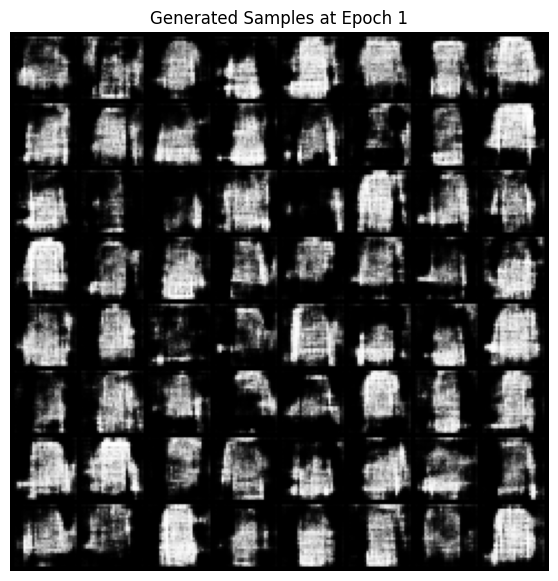

CGAN Epoch [2/50] | Loss D: 0.5650 | Loss G: 2.7434
CGAN Epoch [3/50] | Loss D: 0.7698 | Loss G: 2.2226
CGAN Epoch [4/50] | Loss D: 0.8903 | Loss G: 1.8206
CGAN Epoch [5/50] | Loss D: 0.9018 | Loss G: 1.7711
CGAN Epoch [6/50] | Loss D: 0.9244 | Loss G: 1.7332
CGAN Epoch [7/50] | Loss D: 0.9404 | Loss G: 1.6991
CGAN Epoch [8/50] | Loss D: 0.9529 | Loss G: 1.6890
CGAN Epoch [9/50] | Loss D: 0.9901 | Loss G: 1.6555
CGAN Epoch [10/50] | Loss D: 0.9854 | Loss G: 1.6416


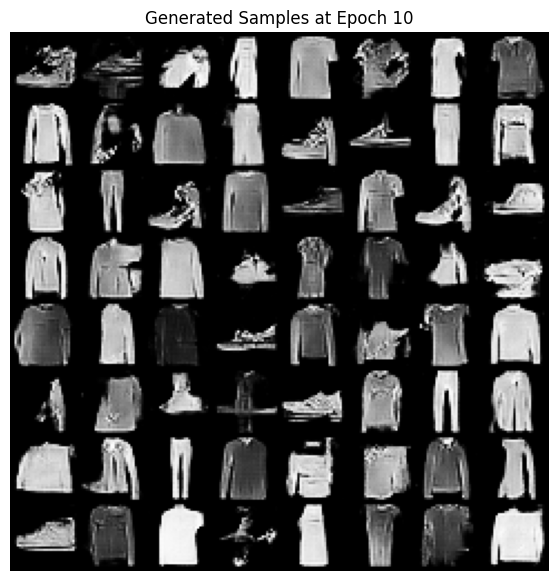

CGAN Epoch [11/50] | Loss D: 0.9962 | Loss G: 1.6357
CGAN Epoch [12/50] | Loss D: 1.0140 | Loss G: 1.6201
CGAN Epoch [13/50] | Loss D: 1.0195 | Loss G: 1.5954
CGAN Epoch [14/50] | Loss D: 1.0390 | Loss G: 1.5736
CGAN Epoch [15/50] | Loss D: 1.0673 | Loss G: 1.5668
CGAN Epoch [16/50] | Loss D: 1.0476 | Loss G: 1.5306
CGAN Epoch [17/50] | Loss D: 1.0661 | Loss G: 1.5179
CGAN Epoch [18/50] | Loss D: 1.1145 | Loss G: 1.4929
CGAN Epoch [19/50] | Loss D: 1.0906 | Loss G: 1.5022
CGAN Epoch [20/50] | Loss D: 1.0904 | Loss G: 1.4834


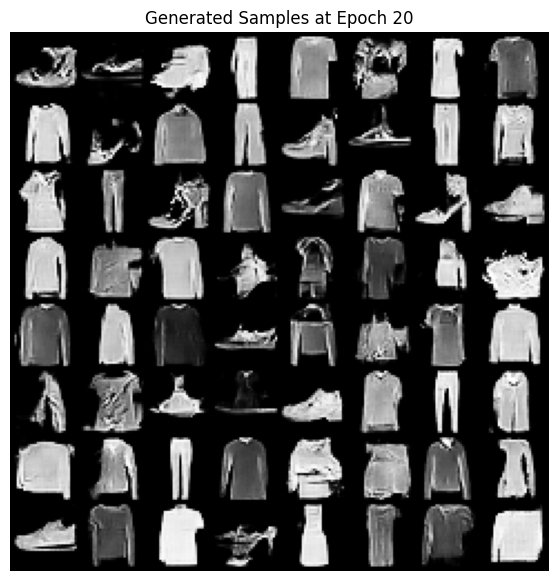

CGAN Epoch [21/50] | Loss D: 1.0953 | Loss G: 1.4722
CGAN Epoch [22/50] | Loss D: 1.1024 | Loss G: 1.4755
CGAN Epoch [23/50] | Loss D: 1.1104 | Loss G: 1.4626
CGAN Epoch [24/50] | Loss D: 1.1124 | Loss G: 1.4613
CGAN Epoch [25/50] | Loss D: 1.1208 | Loss G: 1.4480
CGAN Epoch [26/50] | Loss D: 1.1249 | Loss G: 1.4483
CGAN Epoch [27/50] | Loss D: 1.1139 | Loss G: 1.4486
CGAN Epoch [28/50] | Loss D: 1.1408 | Loss G: 1.4415
CGAN Epoch [29/50] | Loss D: 1.1280 | Loss G: 1.4249
CGAN Epoch [30/50] | Loss D: 1.1805 | Loss G: 1.4390


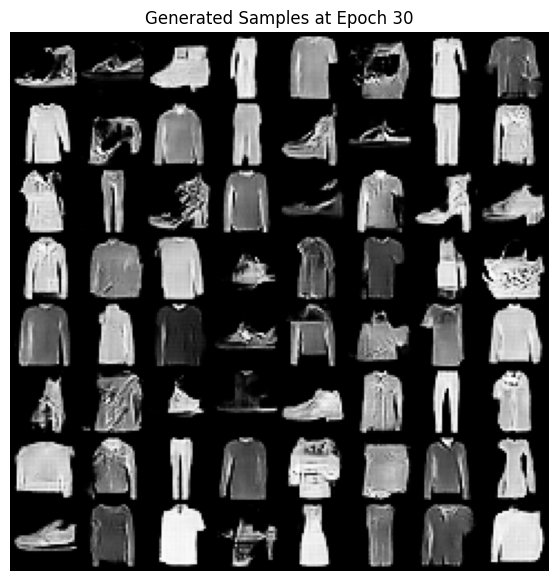

CGAN Epoch [31/50] | Loss D: 1.1286 | Loss G: 1.3959
CGAN Epoch [32/50] | Loss D: 1.1365 | Loss G: 1.4063
CGAN Epoch [33/50] | Loss D: 1.1505 | Loss G: 1.4039
CGAN Epoch [34/50] | Loss D: 1.1522 | Loss G: 1.4021
CGAN Epoch [35/50] | Loss D: 1.1498 | Loss G: 1.3929
CGAN Epoch [36/50] | Loss D: 1.1487 | Loss G: 1.3944
CGAN Epoch [37/50] | Loss D: 1.1616 | Loss G: 1.3920
CGAN Epoch [38/50] | Loss D: 1.1530 | Loss G: 1.3810
CGAN Epoch [39/50] | Loss D: 1.1579 | Loss G: 1.3810
CGAN Epoch [40/50] | Loss D: 1.1646 | Loss G: 1.3819


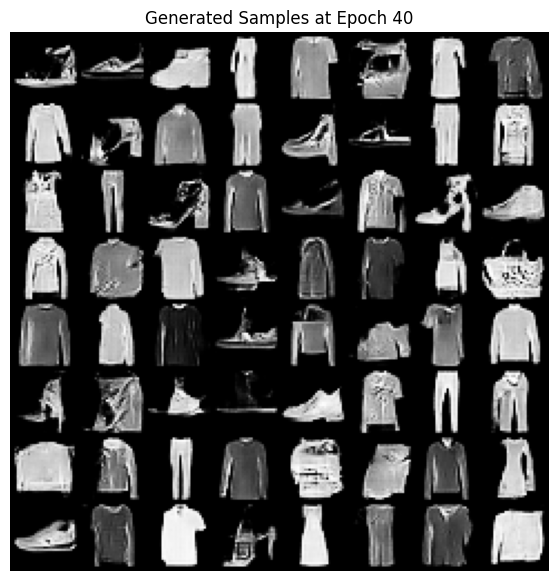

CGAN Epoch [41/50] | Loss D: 1.1610 | Loss G: 1.3739
CGAN Epoch [42/50] | Loss D: 1.1739 | Loss G: 1.3793
CGAN Epoch [43/50] | Loss D: 1.1602 | Loss G: 1.3770
CGAN Epoch [44/50] | Loss D: 1.1693 | Loss G: 1.3640
CGAN Epoch [45/50] | Loss D: 1.1752 | Loss G: 1.3583
CGAN Epoch [46/50] | Loss D: 1.1902 | Loss G: 1.3628
CGAN Epoch [47/50] | Loss D: 1.1603 | Loss G: 1.3530
CGAN Epoch [48/50] | Loss D: 1.1772 | Loss G: 1.3486
CGAN Epoch [49/50] | Loss D: 1.1800 | Loss G: 1.3553
CGAN Epoch [50/50] | Loss D: 1.1727 | Loss G: 1.3470


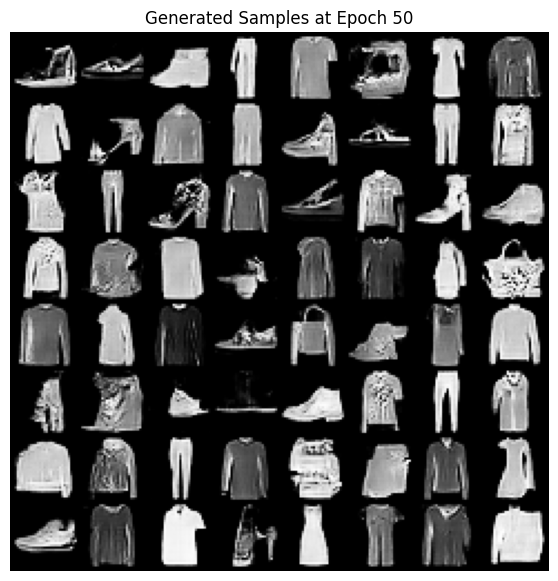

In [16]:
# ============================================================
# Train Convolutional GAN with 50 Epochs and TTUR
# ============================================================

z_dim = 100
gan_epochs = 50
lr_D = 0.0003
lr_G = 0.0001

generator = ConvGenerator(z_dim=z_dim).to(device)
discriminator = ConvDiscriminator().to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)

print("Training Convolutional GAN with adjusted TTUR learning rates")
print(f"Epochs: {gan_epochs}, lr_D: {lr_D}, lr_G: {lr_G}")

gan_history = train_conv_gan_tuned(
    generator=generator,
    discriminator=discriminator,
    train_loader=gan_train_loader,
    z_dim=z_dim,
    epochs=gan_epochs,
    lr_D=lr_D,
    lr_G=lr_G
)

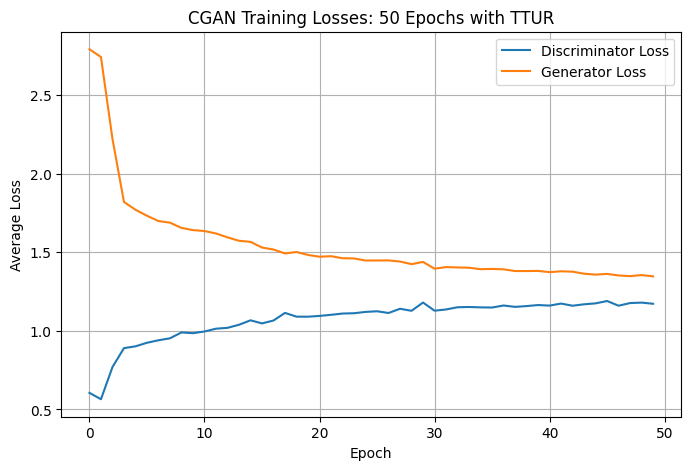

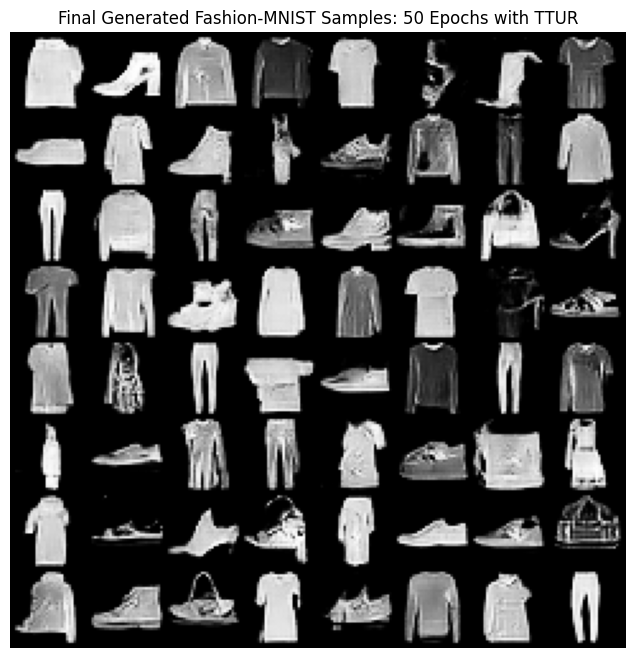

Final GAN loss values:
Final Discriminator Loss: 1.1727
Final Generator Loss: 1.3470


In [17]:
# ============================================================
# Final GAN Visualizations
# ============================================================

plot_gan_losses(gan_history, title="CGAN Training Losses: 50 Epochs with TTUR")
show_generated_samples(
    generator,
    z_dim=z_dim,
    num_images=64,
    title="Final Generated Fashion-MNIST Samples: 50 Epochs with TTUR"
)

print("Final GAN loss values:")
print(f"Final Discriminator Loss: {gan_history['D_loss'][-1]:.4f}")
print(f"Final Generator Loss: {gan_history['G_loss'][-1]:.4f}")

## Homework 2 Analysis: Extended Training and TTUR Learning Rate Adjustment for CGAN

In this experiment, the Convolutional GAN was trained on Fashion-MNIST for 50 epochs using an adjusted Two Time-Scale Update Rule (TTUR) learning rate setting. The Discriminator learning rate was set to `lr_D = 0.0003`, while the Generator learning rate was set to `lr_G = 0.0001`. This means that the Discriminator was updated with a learning rate three times larger than the Generator learning rate. The purpose of this setting was to keep the Discriminator strong enough to provide useful feedback to the Generator during adversarial training, while allowing the Generator to improve more gradually and stably.

The training loss logs show that the Generator loss decreased steadily throughout training. At the beginning of training, the Generator loss was approximately **2.7930** in epoch 1. By the end of epoch 50, it decreased to **1.3470**. This decreasing trend indicates that the Generator gradually became better at producing fake Fashion-MNIST-like images that could confuse the Discriminator. In other words, the Generator learned more realistic image structures as training progressed.

The Discriminator loss followed the opposite trend. It started at approximately **0.6056** in epoch 1 and increased to **1.1727** by epoch 50. At first, this may look like the Discriminator performance became worse. However, in GAN training, this does not necessarily mean that the model failed. GAN losses should not be interpreted in the same way as ordinary supervised learning losses. Since the Generator and Discriminator are trained against each other, their losses naturally change depending on the balance between the two networks. As the Generator improves, the generated images become harder to distinguish from real images, so the Discriminator loss may increase. Therefore, the increasing Discriminator loss in my result suggests that the Generator became more competitive over time.

The loss curve also shows that the largest changes happened during the early epochs. The Generator loss dropped sharply during the first few epochs, while the Discriminator loss increased quickly. After approximately epoch 10 to 15, both losses became more stable and changed more gradually. This suggests that the training process reached a more balanced adversarial stage. The Generator continued to improve slowly, while the Discriminator did not collapse or become extremely weak. The final losses, `Loss D = 1.1727` and `Loss G = 1.3470`, show that both networks were still learning and competing with each other rather than one network completely dominating the other.

Compared to the initial 10-epoch CGAN experiment with default learning rates, the extended 50-epoch training clearly improved the generated image quality. A short 10-epoch run usually produces noisier and less recognizable outputs because the Generator has not had enough time to learn the visual patterns of the dataset. With 50 epochs, the generated samples became more structured and more similar to Fashion-MNIST clothing items. In the final generated image grid, many images show recognizable categories such as shirts, shoes, trousers, dresses, bags, and coats. The object silhouettes are more visible, and several samples have clear outlines instead of random noise.

The adjusted TTUR learning rates also helped the training become more stable. Using a larger learning rate for the Discriminator allowed it to learn faster and provide meaningful gradients to the Generator. At the same time, the smaller Generator learning rate prevented the Generator from changing too aggressively. This helped reduce unstable oscillations and allowed the Generator loss to decrease gradually. The loss curves do not show sudden divergence or extreme instability, which suggests that the selected TTUR setting was reasonable for this experiment.

In terms of diversity, the final generated image grid shows a good variety of Fashion-MNIST-like samples. The Generator did not produce only one repeated type of image. Instead, the outputs include different clothing structures such as shoes, tops, trousers, dresses, and bags. This indicates that the Generator learned multiple modes of the Fashion-MNIST distribution rather than collapsing into a single output pattern.

I did not observe strong signs of mode collapse in the final results. Mode collapse would appear if most generated samples looked almost identical or if the Generator produced only one clothing category repeatedly. In my generated grid, the samples are not identical and represent multiple visual categories. However, some generated images are still blurry, distorted, or incomplete. This means that although the model learned useful data patterns, it did not perfectly capture the full Fashion-MNIST distribution. Therefore, there may be minor quality limitations, but there is no severe mode collapse.

Overall, increasing the training duration from 10 epochs to 50 epochs improved the quality and diversity of the generated images. The Generator learned clearer clothing-like shapes, and the final sample grid showed multiple Fashion-MNIST categories. The TTUR setting with `lr_D = 0.0003` and `lr_G = 0.0001` helped maintain a relatively stable adversarial training process. The decreasing Generator loss and the diverse final generated samples suggest that the extended training and adjusted learning rates improved the CGAN performance compared to the shorter default training setup.

### Summary of Observations

The 50-epoch CGAN training with TTUR improved the generated image quality compared to a short 10-epoch run. The Generator loss decreased from **2.7930** to **1.3470**, showing that the Generator became better at producing realistic Fashion-MNIST-like samples. The Discriminator loss increased from **0.6056** to **1.1727**, but this is expected because the Generator became stronger and made the Discriminator task more difficult. The final generated images show different clothing types, including shoes, shirts, trousers, dresses, and bags. Therefore, I did not observe severe mode collapse. Some samples are still blurry or distorted, but the overall diversity and structure improved with longer training and TTUR learning rates.

## Conclusion

This homework explored the effect of latent dimension size in a Convolutional VAE and the effect of extended training with TTUR learning rates in a Convolutional GAN. For the CVAE experiments, both `latent_dim = 10` and `latent_dim = 50` learned meaningful Fashion-MNIST representations. The `latent_dim = 10` model achieved a slightly lower final total loss and smoother interpolation, while the `latent_dim = 50` model produced slightly sharper reconstructions with more visual detail. This shows the trade-off between compact latent representation and reconstruction capacity.

For the CGAN experiment, training was extended to 50 epochs using `lr_D = 0.0003` and `lr_G = 0.0001`. The Generator loss decreased steadily to **1.3470**, while the Discriminator loss increased to **1.1727**, which suggests that the Generator became stronger and made the Discriminator task more difficult. The final generated images showed recognizable Fashion-MNIST clothing types and reasonable diversity. No severe mode collapse was observed because the generated samples included different categories such as shoes, shirts, trousers, dresses, and bags.

Therefore, the stronger settings for this homework are:

- **CVAE:** `latent_dim = 50`, `beta = 1.5`, `epochs = 10`
- **CGAN:** `epochs = 50`, `lr_D = 0.0003`, `lr_G = 0.0001`

Overall, the experiments showed that generative model performance depends strongly on both representation capacity and training configuration. A larger CVAE latent space can improve reconstruction quality, while TTUR and longer GAN training can improve sample quality and diversity.